In [2]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 34.0 MB/s eta 0:00:0000:0100:01


In [3]:
!pip install anndata==0.8.0

In [1]:
def inc_edge(G, u, v):
    if G.has_edge(u, v):
        G[u][v]['weight'] += 1
    else:
        G.add_edge(u, v, weight=1)

In [7]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import networkx as nx
from collections import defaultdict

In [201]:
G = nx.DiGraph()

In [11]:
sam_cj = SAM()
sam_cj.load_data('Active_SAM_joined/SAM_CJ_joined_v2_cleaned_geneexp_NN_06192025.h5ad')

In [12]:
sam_ac = SAM()
sam_ac.load_data('Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_NN_geneexp_06192025.h5ad')

In [13]:
sam_xt = SAM()
sam_xt.load_data('Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_NN_geneexp_06192025.h5ad')

In [14]:
sam_dr = SAM()
sam_dr.load_data('Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_11202025.h5ad')

In [15]:
level = 'ss_subclass_v3_nounlabeled'

In [202]:
for item in sam_cj.adata.obs[level]:
    if item[:2] == 'cj' and item[3] != 'm':
        G.add_node(item)
        
for item in sam_ac.adata.obs[level]:
    if item[:2] == 'ac'and item[3] != 'm':
        G.add_node(item)

for item in sam_xt.adata.obs[level]:
    if item[:2] == 'xt'and item[3] != 'm':
        G.add_node(item)

for item in sam_dr.adata.obs[level]:
    if item[:2] == 'dr'and item[3] != 'm':
        G.add_node(item)

In [10]:
sm = load_samap('Active_SAMap_Joined/active_samap/Non-mammal/sm_xt_dr_ncbi_cleaned_03272025.pkl')

In [16]:
sam_one = sam_xt

In [17]:
sam_two = sam_dr

In [18]:
org_one_saturn = pd.read_csv('SATURN_mapping/zebrafish_XT_ss3_30_seeds.csv', index_col = 'barcode')
org_two_saturn = pd.read_csv('SATURN_mapping/frog_DR_ss3_30_seeds.csv', index_col = 'barcode')

In [19]:
org_one = 'xt'
org_two = 'dr'

In [20]:
sm.sams[org_one].adata.obs['ss_subclass_v3_nounlabeled'] = pd.read_csv('XT_ss_subclass_v3_nounlabeled_06182025.csv',index_col = 'Unnamed: 0')

In [21]:
sm.sams[org_two].adata.obs['ss_subclass_v3_nounlabeled'] = pd.read_csv('DR_ss_subclass_v3_nounlabeled_06182025.csv',index_col = 'Unnamed: 0')

In [27]:
sm.sams['dr'].adata.obs['ss_subclass_v3_nounlabeled'].unique()

array(['dr_14', '322 Tanycyte NN', 'dr_2_10', 'dr_4', '333 Endo NN',
       'dr_6', 'dr_8', '337 DC NN', '326 OPC NN', '330 VLMC NN', 'dr_16',
       'dr_1', '328 OEC NN', 'dr_22_7', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       'dr_24', '056 Sst Chodl Gaba', 'dr_15',
       '070 LSX Prdm12 Slit2 Gaba', '038 DG-PIR Ex IMN', 'dr_3_21_32',
       '327 Oligo NN', 'dr_5_14', 'dr_20', 'dr_21', '101 ZI Pax6 Gaba',
       'dr_17', 'dr_9', 'dr_13', 'dr_35', 'dr_0', 'dr_23', 'dr_18',
       '086 MPO-ADP Lhx8 Gaba', '104 TU-ARH Otp Six6 Gaba',
       '107 DMH Hmx2 Gaba', 'dr_11', '132 AHN-RCH-LHA Otp Fezf1 Glut',
       'dr_12', 'dr_19_28', '041 OB-in Frmd7 Gaba',
       '111 TRS-BAC Sln Glut', '075 MEA-BST Lhx6 Nr2e1 Gaba',
       '045 OB-STR-CTX Inh IMN', 'dr_31', 'dr_37', 'dr_m041_m064',
       'dr_40', '128 VMH Fezf1 Glut', 'dr_25', 'dr_39', 'dr_26',
       '131 LHA-AHN-PVH Otp Trh Glut', '338 Lymphoid NN',
       '323 Ependymal NN', 'dr_36', '077 CEA-BST Gal Avp Gaba',
       '064 STR-PAL Chst9 Ga

In [192]:
NN_one = set(sm.sams[org_one].adata.obs[level]) - set(sam_one.adata.obs[level])

In [193]:
NN_two = set(sm.sams[org_two].adata.obs[level]) - set(sam_two.adata.obs[level])

In [194]:
NN_one

{'322 Tanycyte NN',
 '326 OPC NN',
 '327 Oligo NN',
 '330 VLMC NN',
 '333 Endo NN',
 'xt_22',
 'xt_40',
 'xt_5'}

In [195]:
NN_two

{'322 Tanycyte NN',
 '323 Ependymal NN',
 '326 OPC NN',
 '327 Oligo NN',
 '328 OEC NN',
 '330 VLMC NN',
 '333 Endo NN',
 '337 DC NN',
 '338 Lymphoid NN',
 'dr_14',
 'dr_21',
 'dr_24',
 'dr_35',
 'dr_37',
 'dr_4'}

In [196]:
sm.sams[org_one].adata.obs['ss_subclass_v3_nounlabeled']

AAACCCAAGATCCAAA Run19_sample1                088 BST Tac2 Gaba
AAACCCAGTACGGATG Run19_sample1           140 PMd-LHA Foxb1 Glut
AAACCCAGTTACGTAC Run19_sample1                            xt_22
AAACCCAGTTCAAACC Run19_sample1            141 PH-SUM Foxa1 Glut
AAACCCATCAGGGTAG Run19_sample1    097 PVHd-SBPV Six3 Prox1 Gaba
                                              ...              
TTTGTTGGTCATAGTC Run19_sample8         094 SCH Six6 Cdc14a Gaba
TTTGTTGGTGAGAGGG Run19_sample8                            xt_17
TTTGTTGGTGTTACTG Run19_sample8          214 IPN Otp Crisp1 Gaba
TTTGTTGTCGGCCCAA Run19_sample8                             xt_9
TTTGTTGTCTTCACAT Run19_sample8                             xt_5
Name: ss_subclass_v3_nounlabeled, Length: 42221, dtype: object

In [197]:
keys = {org_one:level,org_two:level}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable =  MappingTable.loc[:,[i for i in MappingTable.columns if i[:2] == org_one]]
lim_MappingTable = lim_MappingTable.loc[[i for i in lim_MappingTable.index if i[:2] == org_two],:]

In [137]:
lim_MappingTable

,ac_013 COAp Grxcr2 Glut,ac_018 L2 IT PPP-APr Glut,ac_022 L5 ET CTX Glut,ac_039 OB Meis2 Thsd7b Gaba,ac_047 Sncg Gaba,ac_054 STR Prox1 Lhx6 Gaba,ac_055 STR Lhx8 Gaba,ac_056 Sst Chodl Gaba,ac_057 NDB-SI-MA-STRv Lhx8 Gaba,ac_058 PAL-STR Gaba-Chol,...,ac_ac_39,ac_ac_4,ac_ac_5,ac_ac_6,ac_ac_7_37,ac_ac_8_14_23,ac_ac_9,ac_ac_m058_m086,ac_ac_m124_m130,ac_ac_m136_m138
xt_009 L2/3 IT PIR-ENTl Glut,0.076262,0.000000,0.018515,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.255807,0.000000,0.000360,0.000000,0.000000,0.000876,0.000000
xt_011 L2 IT ENT-po Glut,0.094140,0.000039,0.077396,0.000085,0.000000,0.000000,0.000000,0.000000,0.000416,0.000000,...,0.0,0.000000,0.000000,0.198150,0.000129,0.000342,0.000301,0.000611,0.000000,0.000000
xt_041 OB-in Frmd7 Gaba,0.000351,0.004993,0.000269,0.865826,0.005686,0.006281,0.000307,0.000231,0.000000,0.000000,...,0.0,0.002705,0.000000,0.004021,0.000000,0.000000,0.004688,0.000000,0.000000,0.000000
xt_054 STR Prox1 Lhx6 Gaba,0.000000,0.000000,0.000000,0.000000,0.007322,0.483343,0.438856,0.004408,0.010981,0.001813,...,0.0,0.000000,0.005386,0.000000,0.000000,0.000000,0.000000,0.000236,0.000000,0.000000
xt_056 Sst Chodl Gaba,0.000000,0.000000,0.000000,0.000000,0.000437,0.156882,0.060221,0.504245,0.001862,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xt_xt_6,0.000000,0.002899,0.000788,0.000000,0.000000,0.000000,0.000000,0.000335,0.000083,0.000000,...,0.0,0.000075,0.000576,0.000619,0.000042,0.000000,0.000552,0.000136,0.042561,0.000913
xt_xt_7,0.000135,0.000324,0.000035,0.000943,0.000000,0.000055,0.000000,0.002447,0.000508,0.000000,...,0.0,0.000134,0.000290,0.000099,0.000086,0.000055,0.003179,0.003687,0.000000,0.000112
xt_xt_8,0.000000,0.000053,0.000000,0.000000,0.000000,0.000000,0.004265,0.000000,0.000000,0.000000,...,0.0,0.000000,0.014322,0.000044,0.000222,0.000404,0.000809,0.006664,0.000000,0.000569
xt_xt_9,0.000459,0.000139,0.000277,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000518,0.001417,0.000344,0.000589,0.001556,0.000000,0.019517,0.001474


In [198]:
org_one_mapping = {}
for item in sm.sams[org_one].adata.obs[level].unique():
    if item in G and item not in NN_one:
        best_match_samap = lim_MappingTable.loc[:,org_one + '_' + item].idxmax()[3:]
        saturn_vals = org_one_saturn.loc[sm.sams[org_one].adata.obs_names[sm.sams[org_one].adata.obs[level] == item],'seed_0']
        best_match_saturn = org_two + '_' + saturn_vals.mode()[0]
        print(lim_MappingTable.loc[org_two + '_' + best_match_samap,org_one + '_' + item])
        print(np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals))
        print(item, best_match_saturn, best_match_samap)
        org_one_mapping[item] = [best_match_samap, best_match_saturn, lim_MappingTable.loc[org_two + '_' + best_match_samap,org_one + '_' + item], 
                                 np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals)]
df = pd.DataFrame.from_dict(org_one_mapping)
df = df.T
df.columns = ['SAMAP match','SATURN match', 'SAMAP score', 'SATURN score']
df.to_csv(org_one + '_' + org_two + '_nonmam_mapping_06282026.csv')

0.150880590292054
0.9422776911076443
xt_4 dr_2_10 dr_22_7
0.10290885350299132
0.9789029535864979
xt_16 dr_333 Endo NN dr_9
0.14373430979765003
0.39069767441860465
xt_11 dr_34 dr_5_14
0.23888936315392936
0.7235668789808917
xt_3_38 dr_3_21_32 dr_5_14
0.10322189798101596
0.70042194092827
xt_15 dr_30 dr_20
0.7407874544679204
0.8597122302158273
xt_13 dr_19_28 dr_1
0.3176487122400925
0.9601634320735445
xt_0 dr_23 dr_23
0.28645707417183786
0.1728395061728395
xt_12 dr_100 AHN Onecut3 Gaba 101 ZI Pax6 Gaba
0.15316680847699773
0.32723112128146453
xt_9 dr_089 PVR Six3 Sox3 Gaba dr_9
0.20579688548344746
0.8919226393629124
xt_1 dr_29 dr_2_10
0.19846854979781553
0.7596899224806202
xt_7 dr_070 LSX Prdm12 Slit2 Gaba dr_6
0.09282506685204298
0.24242424242424243
xt_41 dr_314 CB Granule Glut dr_5_14
0.16379658316245557
0.13
xt_20 dr_323 Ependymal NN 077 CEA-BST Gal Avp Gaba
0.1335700307077748
0.9607843137254902
xt_33 dr_100 AHN Onecut3 Gaba dr_5_14
0.37746240894720234
0.18867924528301888
xt_25 dr_070 LSX

In [199]:
org_two_mapping = {}
for item in sm.sams[org_two].adata.obs[level].unique():
    if item in G and item not in NN_two:
        best_match_samap = lim_MappingTable.loc[org_two + '_' + item,:].idxmax()[3:]
        saturn_vals = org_two_saturn.loc[sm.sams[org_two].adata.obs_names[sm.sams[org_two].adata.obs[level] == item],'seed_0']
        best_match_saturn = org_one + '_' + saturn_vals.mode()[0]
        print(lim_MappingTable.loc[org_two + '_' + item,org_one + '_' + best_match_samap])
        print(np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals))
        print(item, best_match_saturn, best_match_samap)
        org_two_mapping[item] = [best_match_samap, best_match_saturn, lim_MappingTable.loc[org_two + '_' + item,org_one + '_' + best_match_samap], 
                                 np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals)]
df = pd.DataFrame.from_dict(org_two_mapping)
df = df.T
df.columns = ['SAMAP match','SATURN match', 'SAMAP score', 'SATURN score']
df.to_csv(org_two + '_' + org_one + '_nonmam_mapping_06282026.csv')

0.20579688548344746
0.6613858217314771
dr_2_10 xt_159 IF-RL-CLI-PAG Foxa1 Glut xt_1
0.2391931187726452
0.7102461743180306
dr_6 xt_094 SCH Six6 Cdc14a Gaba xt_21
0.20561006221867953
0.9408262002232973
dr_8 xt_079 CEA-BST Six3 Cyp26b1 Gaba 082 CEA-BST Ebf1 Pdyn Gaba
0.0894647738813655
0.809282700421941
dr_16 xt_181 IC Tfap2d Maf Glut xt_36
0.8960631072750603
0.9975385992392034
dr_1 xt_145 MH Tac2 Glut 145 MH Tac2 Glut
0.5655015208614738
0.691594039921282
dr_22_7 xt_17 181 IC Tfap2d Maf Glut
0.4571835638291509
0.809041309431021
dr_15 xt_138 PH Pitx2 Glut 168 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut
0.19619981406302828
0.9115774581466636
dr_3_21_32 xt_098 AHN-SBPV-PVHd Pdrm12 Gaba 138 PH Pitx2 Glut
0.3468713522591821
0.9399423026488329
dr_5_14 xt_2 xt_14
0.12166432690760334
0.9290123456790124
dr_20 xt_262 Pineal Crx Glut 106 PVpo-VMPO-MPN Hmx2 Gaba
0.20649137494473585
0.5017543859649123
dr_17 xt_073 MEA-BST Sox6 Gaba 073 MEA-BST Sox6 Gaba
0.3007435974670095
0.9574082464884458
dr_9 xt_125 DMH Hmx

In [4]:
m = pd.read_csv('cj_xt_nonmam_mapping_06282026.csv', index_col = 'Unnamed: 0')
mr = pd.read_csv('xt_cj_nonmam_mapping_06282026.csv', index_col = 'Unnamed: 0')

In [5]:
m

,SAMAP match,SATURN match,SAMAP score,SATURN score
cj_3,xt_3_38,xt_3_38,0.259677,0.874336
cj_8,xt_25,xt_8,0.095430,0.455696
cj_4,xt_21,xt_098 AHN-SBPV-PVHd Pdrm12 Gaba,0.131480,0.887868
cj_9,xt_25,xt_277 DTN-LDT-IPN Otp Pax3 Gaba,0.142767,0.731903
cj_20,090 BST-MPN Six3 Nrgn Gaba,xt_088 BST Tac2 Gaba,0.112743,0.551867
cj_6,xt_30,xt_214 IPN Otp Crisp1 Gaba,0.141900,0.461694
cj_7,122 LHA-MEA Otp Glut,xt_140 PMd-LHA Foxb1 Glut,0.165830,0.503480
cj_16,xt_7,xt_7,0.517335,0.523810
cj_5,xt_18,xt_103 PVHd-DMH Lhx6 Gaba,0.574895,0.659491
cj_14,xt_14,xt_14,0.438859,0.584375


In [6]:
mr

,SAMAP match,SATURN match,SAMAP score,SATURN score
xt_4,013 COAp Grxcr2 Glut,cj_18,0.815749,0.369735
xt_16,cj_17,cj_153 MG-POL-SGN Nts Glut,0.019045,0.713080
xt_11,cj_33,cj_213 SCsg Gabrr2 Gaba,0.149578,0.600000
xt_3_38,cj_3,cj_3,0.259677,0.877707
xt_15,102 DMH-LHA Gsx1 Gaba,cj_108 ARH-PVp Tbx3 Gaba,0.046523,0.742616
xt_13,cj_26,cj_123 DMH Nkx2-4 Glut,0.302576,0.741007
xt_0,cj_2,cj_203 LGv-SPFp-SPFm Nkx2-2 Tcf7l2 Gaba,0.545579,0.526047
xt_12,101 ZI Pax6 Gaba,cj_085 SI-MPO-LPO Lhx8 Gaba,0.288745,0.145062
xt_9,124 MPN-MPO-PVpo Hmx2 Glut,cj_124 MPN-MPO-PVpo Hmx2 Glut,0.273571,0.762014
xt_1,164 APN C1ql4 Glut,cj_1,0.838458,0.777019


In [242]:
#including directed edges
def incl_directed(G, df):
    for output_node, row in df.iterrows():
        if row[0] in G.nodes():
            G.add_edge(output_node,row[0])
        if row[1] in G.nodes():
            G.add_edge(output_node,row[1])

In [243]:
incl_directed(G,m)
incl_directed(G,mr)

In [244]:
G.edges

OutEdgeView([('cj_3', 'ac_0'), ('cj_3', 'xt_3_38'), ('cj_8', 'xt_8'), ('cj_4', 'xt_21'), ('cj_9', 'dr_34'), ('cj_6', 'ac_18'), ('cj_6', 'xt_30'), ('cj_6', 'dr_26'), ('cj_7', 'dr_25'), ('cj_16', 'xt_7'), ('cj_5', 'xt_18'), ('cj_14', 'xt_14'), ('cj_25', 'xt_19'), ('cj_21', 'ac_13'), ('cj_21', 'dr_16'), ('cj_2', 'ac_3'), ('cj_2', 'xt_0'), ('cj_2', 'dr_23'), ('cj_1', 'ac_1_19'), ('cj_1', 'xt_1'), ('cj_18', 'xt_4'), ('cj_26', 'xt_13'), ('cj_26', 'dr_1'), ('cj_11', 'xt_26'), ('cj_13', 'xt_2'), ('cj_12', 'ac_8_14_23'), ('ac_15', 'xt_30'), ('ac_15', 'dr_26'), ('ac_0', 'cj_3'), ('ac_0', 'xt_3_38'), ('ac_0', 'dr_3_21_32'), ('ac_5', 'dr_13'), ('ac_13', 'cj_21'), ('ac_13', 'dr_15'), ('ac_13', 'dr_19_28'), ('ac_3', 'cj_2'), ('ac_3', 'xt_0'), ('ac_3', 'dr_23'), ('ac_10', 'xt_15'), ('ac_10', 'dr_11'), ('ac_21', 'dr_5_14'), ('ac_21', 'dr_36'), ('ac_1_19', 'cj_1'), ('ac_1_19', 'xt_1'), ('ac_1_19', 'dr_3_21_32'), ('ac_1_19', 'dr_16'), ('ac_7_37', 'xt_31'), ('ac_7_37', 'dr_2_10'), ('ac_7_37', 'dr_19_28')

In [245]:
mutual_edges = [(u, v) for u, v in G.edges() if G.has_edge(v, u)]

In [246]:
non_mutual = [(u, v) for u, v in G.edges() if not G.has_edge(v, u)]
G.remove_edges_from(non_mutual)

In [208]:
# Build edge sets by method, mirroring the logic in incl_directed
samap_edges = set()
saturn_edges = set()

for output_node, row in m.iterrows():
    if row[0] in G.nodes():
        samap_edges.add((output_node, row[0]))
    if row[1] in G.nodes():
        saturn_edges.add((output_node, row[1]))

for output_node, row in mr.iterrows():
    if row[0] in G.nodes():
        samap_edges.add((output_node, row[0]))
    if row[1] in G.nodes():
        saturn_edges.add((output_node, row[1]))

# Count each undirected pair once (every edge in G is mutual, so u->v and v->u both exist)
seen = set()
both_count = 0
samap_only = 0
saturn_only = 0

for u, v in G.edges():
    if (v, u) in seen:
        continue
    seen.add((u, v))
    found_samap = (u, v) in samap_edges or (v, u) in samap_edges
    found_saturn = (u, v) in saturn_edges or (v, u) in saturn_edges
    if found_samap and found_saturn:
        both_count += 1
    elif found_samap:
        samap_only += 1
    else:
        saturn_only += 1

total = both_count + samap_only + saturn_only
print(f'Total mutual edges (unique pairs): {total}')
print(f'  Both SAMap and SATURN: {both_count} ({100*both_count/total:.1f}%)')
print(f'  SAMap only:            {samap_only} ({100*samap_only/total:.1f}%)')
print(f'  SATURN only:           {saturn_only} ({100*saturn_only/total:.1f}%)')

Total mutual edges (unique pairs): 12
  Both SAMap and SATURN: 5 (41.7%)
  SAMap only:            3 (25.0%)
  SATURN only:           4 (33.3%)


In [247]:
G.edges()

OutEdgeView([('cj_3', 'ac_0'), ('cj_3', 'xt_3_38'), ('cj_8', 'xt_8'), ('cj_4', 'xt_21'), ('cj_9', 'dr_34'), ('cj_6', 'ac_18'), ('cj_6', 'xt_30'), ('cj_6', 'dr_26'), ('cj_7', 'dr_25'), ('cj_16', 'xt_7'), ('cj_5', 'xt_18'), ('cj_14', 'xt_14'), ('cj_25', 'xt_19'), ('cj_21', 'ac_13'), ('cj_21', 'dr_16'), ('cj_2', 'ac_3'), ('cj_2', 'xt_0'), ('cj_2', 'dr_23'), ('cj_1', 'ac_1_19'), ('cj_1', 'xt_1'), ('cj_18', 'xt_4'), ('cj_26', 'xt_13'), ('cj_26', 'dr_1'), ('cj_11', 'xt_26'), ('cj_13', 'xt_2'), ('cj_12', 'ac_8_14_23'), ('ac_15', 'xt_30'), ('ac_15', 'dr_26'), ('ac_0', 'cj_3'), ('ac_0', 'xt_3_38'), ('ac_0', 'dr_3_21_32'), ('ac_5', 'dr_13'), ('ac_13', 'cj_21'), ('ac_3', 'cj_2'), ('ac_3', 'xt_0'), ('ac_3', 'dr_23'), ('ac_10', 'xt_15'), ('ac_1_19', 'cj_1'), ('ac_1_19', 'xt_1'), ('ac_1_19', 'dr_16'), ('ac_7_37', 'xt_31'), ('ac_18', 'cj_6'), ('ac_33', 'xt_39'), ('ac_33', 'dr_11'), ('ac_28', 'dr_9'), ('ac_2', 'dr_2_10'), ('ac_17_20', 'xt_17'), ('ac_8_14_23', 'cj_12'), ('ac_8_14_23', 'dr_30'), ('ac_6'

In [248]:
undirected = G.to_undirected()

# Build dictionary mapping each node to its component ID
node_to_component = {}
for component_id, component in enumerate(nx.connected_components(undirected)):
    if len(component) > 1:  # skip isolated nodes
        for node in component:
            node_to_component[node] = component_id

In [249]:
G.edges()

OutEdgeView([('cj_3', 'ac_0'), ('cj_3', 'xt_3_38'), ('cj_8', 'xt_8'), ('cj_4', 'xt_21'), ('cj_9', 'dr_34'), ('cj_6', 'ac_18'), ('cj_6', 'xt_30'), ('cj_6', 'dr_26'), ('cj_7', 'dr_25'), ('cj_16', 'xt_7'), ('cj_5', 'xt_18'), ('cj_14', 'xt_14'), ('cj_25', 'xt_19'), ('cj_21', 'ac_13'), ('cj_21', 'dr_16'), ('cj_2', 'ac_3'), ('cj_2', 'xt_0'), ('cj_2', 'dr_23'), ('cj_1', 'ac_1_19'), ('cj_1', 'xt_1'), ('cj_18', 'xt_4'), ('cj_26', 'xt_13'), ('cj_26', 'dr_1'), ('cj_11', 'xt_26'), ('cj_13', 'xt_2'), ('cj_12', 'ac_8_14_23'), ('ac_15', 'xt_30'), ('ac_15', 'dr_26'), ('ac_0', 'cj_3'), ('ac_0', 'xt_3_38'), ('ac_0', 'dr_3_21_32'), ('ac_5', 'dr_13'), ('ac_13', 'cj_21'), ('ac_3', 'cj_2'), ('ac_3', 'xt_0'), ('ac_3', 'dr_23'), ('ac_10', 'xt_15'), ('ac_1_19', 'cj_1'), ('ac_1_19', 'xt_1'), ('ac_1_19', 'dr_16'), ('ac_7_37', 'xt_31'), ('ac_18', 'cj_6'), ('ac_33', 'xt_39'), ('ac_33', 'dr_11'), ('ac_28', 'dr_9'), ('ac_2', 'dr_2_10'), ('ac_17_20', 'xt_17'), ('ac_8_14_23', 'cj_12'), ('ac_8_14_23', 'dr_30'), ('ac_6'

In [5]:
mr.loc['dr_31',:]

SAMAP match        xt_22
SATURN match       xt_34
SAMAP score     0.072026
SATURN score    0.947743
Name: dr_31, dtype: object

In [250]:
groups = defaultdict(list)
for key, val in node_to_component.items():
    groups[val].append(key)

# Track counters per prefix-combo
combo_counters = defaultdict(int)
result = {}

prefix_order = ['cj', 'ac', 'xt', 'dr']
for val, keys in groups.items():
    prefixes = sorted(set(k.split('_')[0] for k in keys), key=lambda x: prefix_order.index(x))
    combo = '_'.join(prefixes)
    combo_counters[combo] += 1
    new_val = f"{combo}_{combo_counters[combo]}"
    for key in keys:
        result[key] = new_val

print(result)

{'cj_3': 'cj_ac_xt_dr_1', 'xt_3_38': 'cj_ac_xt_dr_1', 'dr_3_21_32': 'cj_ac_xt_dr_1', 'ac_0': 'cj_ac_xt_dr_1', 'cj_8': 'cj_xt_1', 'xt_8': 'cj_xt_1', 'xt_21': 'cj_xt_dr_1', 'dr_6': 'cj_xt_dr_1', 'cj_4': 'cj_xt_dr_1', 'dr_34': 'cj_dr_1', 'cj_9': 'cj_dr_1', 'ac_15': 'cj_ac_xt_dr_2', 'ac_18': 'cj_ac_xt_dr_2', 'dr_26': 'cj_ac_xt_dr_2', 'cj_6': 'cj_ac_xt_dr_2', 'xt_30': 'cj_ac_xt_dr_2', 'cj_7': 'cj_dr_2', 'dr_25': 'cj_dr_2', 'cj_16': 'cj_xt_2', 'xt_7': 'cj_xt_2', 'xt_18': 'cj_xt_3', 'cj_5': 'cj_xt_3', 'dr_5_14': 'cj_xt_dr_2', 'cj_13': 'cj_xt_dr_2', 'xt_2': 'cj_xt_dr_2', 'cj_14': 'cj_xt_dr_2', 'xt_14': 'cj_xt_dr_2', 'cj_25': 'cj_xt_4', 'xt_19': 'cj_xt_4', 'dr_16': 'cj_ac_xt_dr_3', 'dr_29': 'cj_ac_xt_dr_3', 'cj_21': 'cj_ac_xt_dr_3', 'cj_1': 'cj_ac_xt_dr_3', 'dr_2_10': 'cj_ac_xt_dr_3', 'ac_2': 'cj_ac_xt_dr_3', 'ac_13': 'cj_ac_xt_dr_3', 'xt_1': 'cj_ac_xt_dr_3', 'xt_36': 'cj_ac_xt_dr_3', 'ac_1_19': 'cj_ac_xt_dr_3', 'cj_2': 'cj_ac_xt_dr_4', 'ac_3': 'cj_ac_xt_dr_4', 'xt_0': 'cj_ac_xt_dr_4', 'dr_23':

In [252]:
node_order = list(G.nodes())
colors = []
for item in node_order:
    if item[:2] == 'cj':
        colors.append('red')
    if item[:2] == 'ac':
        colors.append('blue')
    if item[:2] == 'xt':
        colors.append('green')
    if item[:2] == 'dr':
        colors.append('purple')

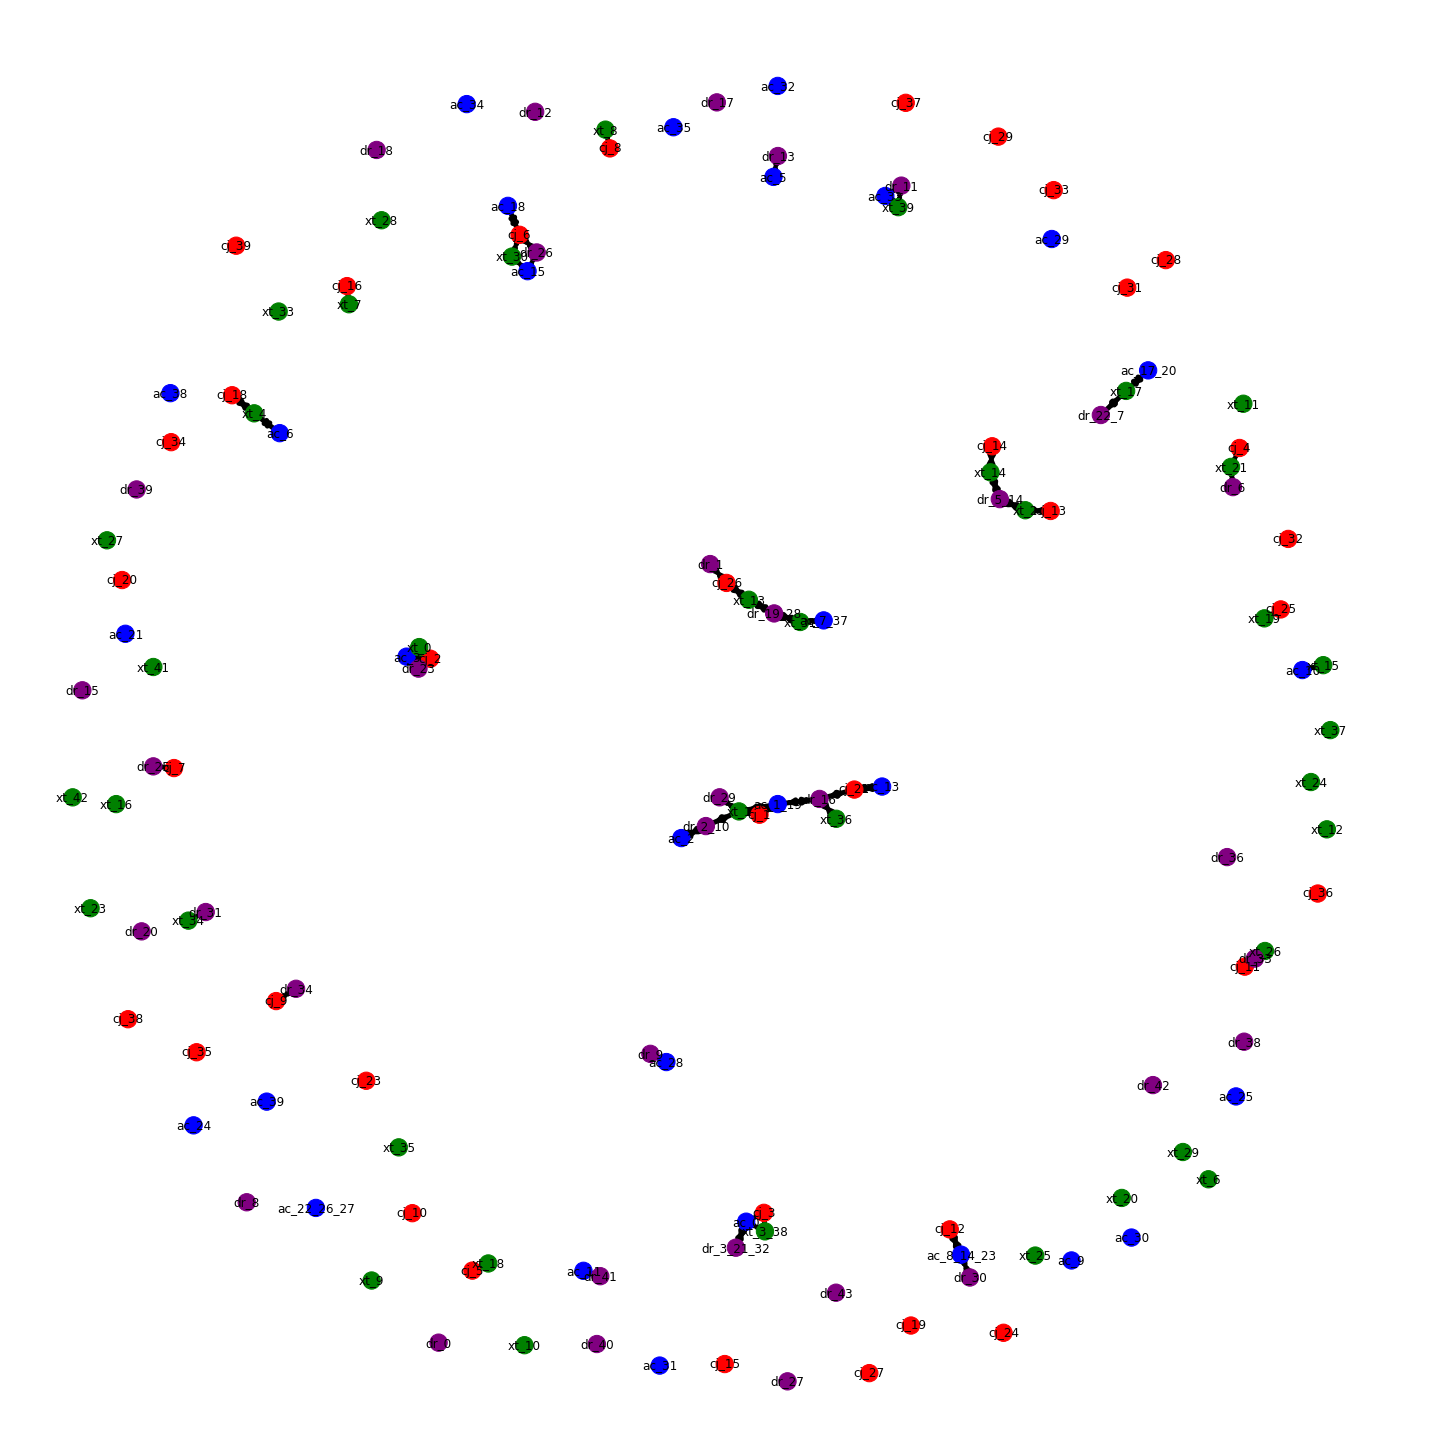

In [253]:
plt.figure(figsize = ((20,20)))
nx.draw(G,with_labels=True,width=5, edge_color='black',node_color = colors)
plt.show()

In [161]:
fin_set = set()
for u,v in G.edges():
    if u[:2] == 'cj':
        fin_set.add(u)
    if v[:2] == 'cj':
        fin_set.add(v)

['blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'red', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red']
['cj_3', 'cj_8', 'cj_4', 'cj_9', 'cj_20', 'cj_6', 'cj_7', 'cj_16', 'cj_5', 'cj_14', 'cj_28', 'cj_15', 'cj_25', 'cj_23', 'cj_21', 'cj_2', 'cj_19', 'cj_10', 'cj_27', 'cj_1', 'cj_18', 'cj_35', 'cj_37', 'cj_34', 'cj_26', 'cj_29', 'cj_32', 'cj_11', 'cj_24', 'cj_13', 'cj_12', 'cj_31', 'cj_36', 'cj_38', 'cj_33', 'cj_39']
[565, 395, 544, 373, 241, 496, 431, 273, 511, 320, 129, 317, 171, 188, 203, 797, 242, 370, 133, 1015, 248, 52, 30, 60, 140, 117, 70, 347, 177, 322, 328, 90, 34, 24, 69, 21]


<BarContainer object of 36 artists>

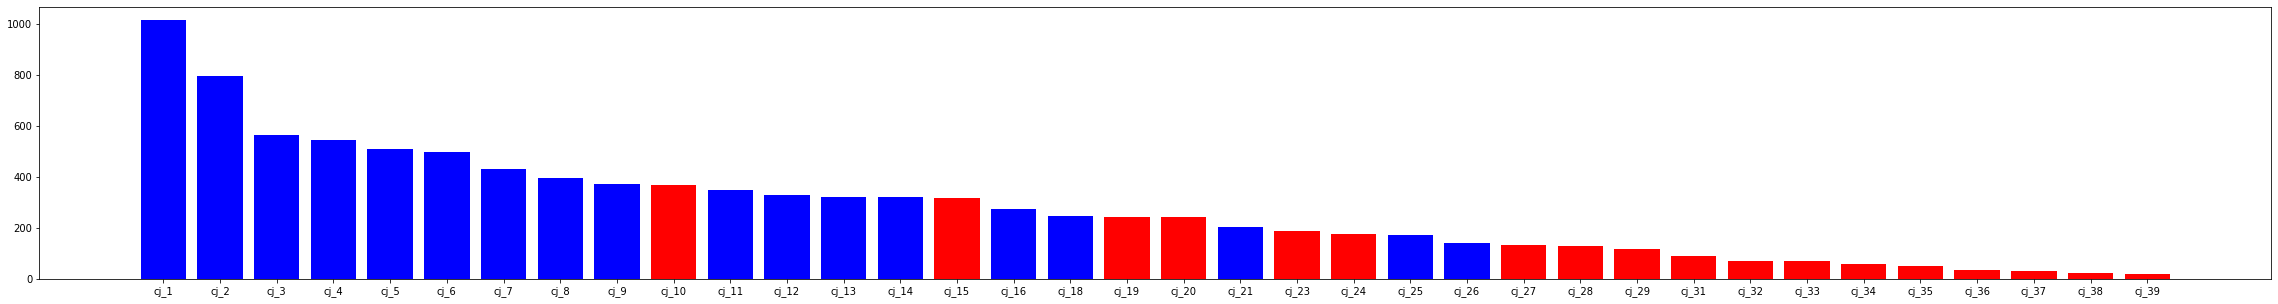

In [162]:
all_len = []
colors = []
xs = []
for item in sam_cj.adata.obs[level].unique():
    if item in G:
        all_len.append(len(sam_cj.adata[sam_cj.adata.obs[level] == item]))
        xs.append(item)
        if item not in fin_set:
            #print(item)
            colors.append('red')
        if item in fin_set:
            #print(item + ' mapped')
            colors.append('blue')
            
sorted_pairs = sorted(zip(all_len,xs,colors), reverse=True)
sorted_values, sorted_names, sorted_colors = zip(*sorted_pairs)

print(colors)
print(xs)
print(all_len)
plt.figure(figsize=(40,5))
plt.bar(x = sorted_names, height = sorted_values, color = sorted_colors)

In [163]:
fin_set = set()
for u,v in G.edges():
    if u[:2] == 'ac':
        fin_set.add(u)
    if v[:2] == 'ac':
        fin_set.add(v)

['red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red']
['ac_15', 'ac_0', 'ac_5', 'ac_13', 'ac_3', 'ac_10', 'ac_21', 'ac_1_19', 'ac_7_37', 'ac_18', 'ac_34', 'ac_9', 'ac_33', 'ac_28', 'ac_2', 'ac_17_20', 'ac_8_14_23', 'ac_31', 'ac_6', 'ac_39', 'ac_11', 'ac_22_26_27', 'ac_30', 'ac_24', 'ac_29', 'ac_25', 'ac_35', 'ac_32', 'ac_38']
[219, 1809, 602, 271, 692, 305, 128, 1491, 553, 186, 29, 458, 44, 72, 819, 354, 830, 52, 560, 20, 398, 154, 57, 85, 63, 79, 25, 44, 23]


<BarContainer object of 29 artists>

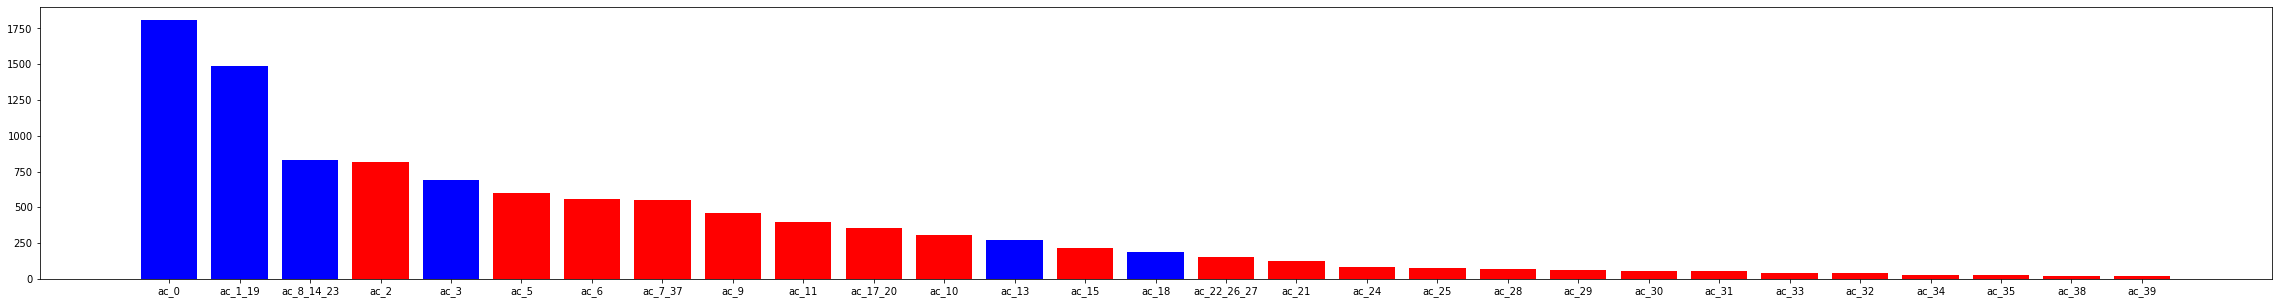

In [164]:
all_len = []
colors = []
xs = []
for item in sam_ac.adata.obs[level].unique():
    if item in G:
        all_len.append(len(sam_ac.adata[sam_ac.adata.obs[level] == item]))
        xs.append(item)
        if item not in fin_set:
            #print(item)
            colors.append('red')
        if item in fin_set:
            #print(item + ' mapped')
            colors.append('blue')
            
sorted_pairs = sorted(zip(all_len,xs,colors), reverse=True)
sorted_values, sorted_names, sorted_colors = zip(*sorted_pairs)

print(colors)
print(xs)
print(all_len)
plt.figure(figsize=(40,5))
plt.bar(x = sorted_names, height = sorted_values, color = sorted_colors)

In [165]:
fin_set = set()
for u,v in G.edges():
    if u[:2] == 'xt':
        fin_set.add(u)
    if v[:2] == 'xt':
        fin_set.add(v)

['blue', 'red', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'blue']
['xt_4', 'xt_16', 'xt_11', 'xt_3_38', 'xt_15', 'xt_13', 'xt_0', 'xt_12', 'xt_9', 'xt_1', 'xt_7', 'xt_41', 'xt_20', 'xt_33', 'xt_25', 'xt_23', 'xt_8', 'xt_6', 'xt_14', 'xt_31', 'xt_27', 'xt_10', 'xt_18', 'xt_28', 'xt_21', 'xt_29', 'xt_26', 'xt_17', 'xt_19', 'xt_24', 'xt_30', 'xt_42', 'xt_39', 'xt_2', 'xt_37', 'xt_35', 'xt_34', 'xt_36']
[641, 237, 430, 785, 237, 278, 979, 324, 437, 879, 516, 33, 200, 102, 159, 175, 438, 531, 243, 109, 134, 431, 216, 131, 182, 113, 142, 225, 207, 162, 112, 29, 40, 835, 71, 90, 95, 87]


<BarContainer object of 38 artists>

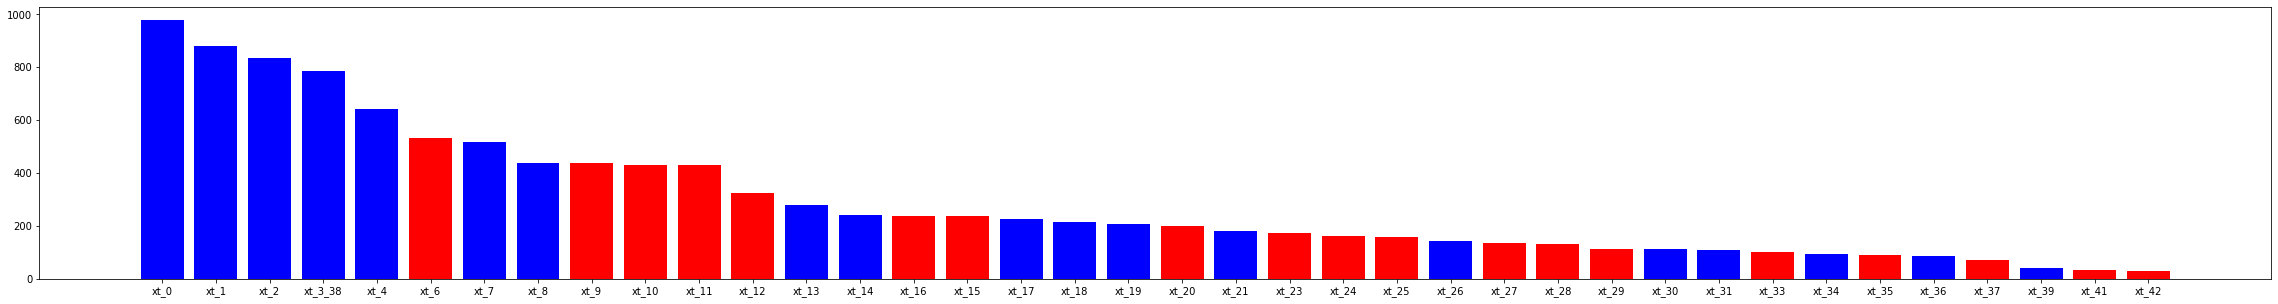

In [166]:
all_len = []
colors = []
xs = []
for item in sam_xt.adata.obs[level].unique():
    if item in G:
        all_len.append(len(sam_xt.adata[sam_xt.adata.obs[level] == item]))
        xs.append(item)
        if item not in fin_set:
            #print(item)
            colors.append('red')
        if item in fin_set:
            #print(item + ' mapped')
            colors.append('blue')
            
sorted_pairs = sorted(zip(all_len,xs,colors), reverse=True)
sorted_values, sorted_names, sorted_colors = zip(*sorted_pairs)

print(colors)
print(xs)
print(all_len)
plt.figure(figsize=(40,5))
plt.bar(x = sorted_names, height = sorted_values, color = sorted_colors)

In [168]:
fin_set = set()
for u,v in G.edges():
    if u[:2] == 'dr':
        fin_set.add(u)
    if v[:2] == 'dr':
        fin_set.add(v)

['blue', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'red', 'red', 'red', 'red', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'blue', 'red', 'blue', 'red', 'red', 'red', 'blue', 'red', 'red', 'red', 'red', 'red', 'blue']
['dr_2_10', 'dr_6', 'dr_8', 'dr_16', 'dr_1', 'dr_22_7', 'dr_15', 'dr_3_21_32', 'dr_5_14', 'dr_20', 'dr_17', 'dr_9', 'dr_13', 'dr_0', 'dr_23', 'dr_18', 'dr_11', 'dr_12', 'dr_19_28', 'dr_31', 'dr_40', 'dr_25', 'dr_39', 'dr_26', 'dr_36', 'dr_33', 'dr_30', 'dr_29', 'dr_41', 'dr_27', 'dr_42', 'dr_38', 'dr_43', 'dr_34']
[6249, 3006, 2687, 1185, 4469, 3557, 1283, 4241, 3813, 972, 1140, 2207, 1427, 4540, 712, 1119, 1949, 1772, 1583, 421, 155, 589, 162, 528, 201, 256, 429, 436, 147, 498, 145, 165, 55, 250]


<BarContainer object of 34 artists>

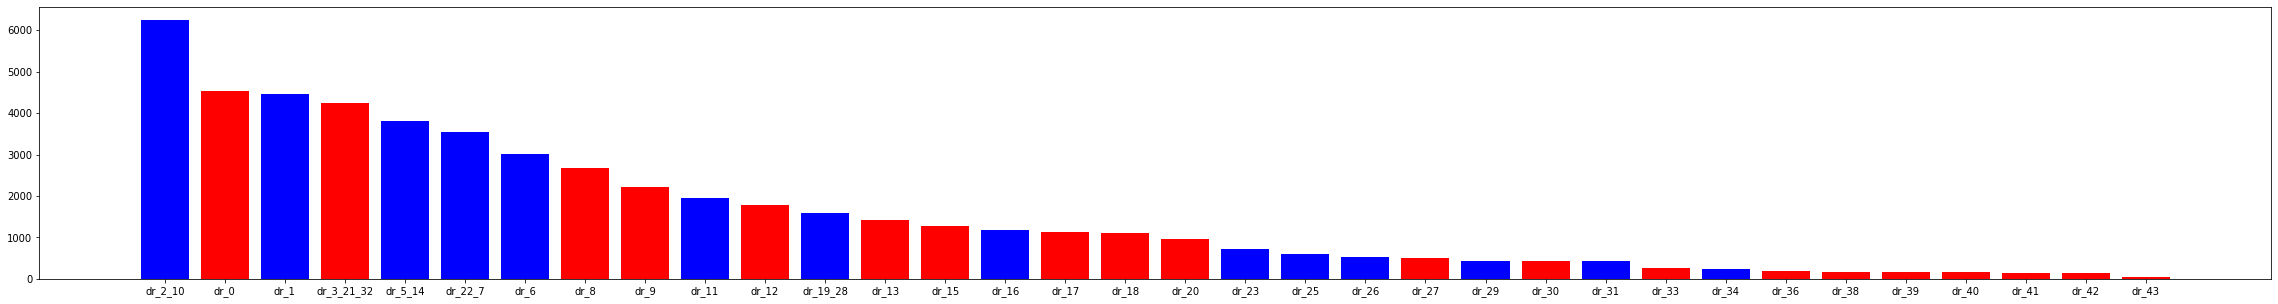

In [169]:
all_len = []
colors = []
xs = []
for item in sam_dr.adata.obs[level].unique():
    if item in G:
        all_len.append(len(sam_dr.adata[sam_dr.adata.obs[level] == item]))
        xs.append(item)
        if item not in fin_set:
            #print(item)
            colors.append('red')
        if item in fin_set:
            #print(item + ' mapped')
            colors.append('blue')
            
sorted_pairs = sorted(zip(all_len,xs,colors), reverse=True)
sorted_values, sorted_names, sorted_colors = zip(*sorted_pairs)

print(colors)
print(xs)
print(all_len)
plt.figure(figsize=(40,5))
plt.bar(x = sorted_names, height = sorted_values, color = sorted_colors)

In [203]:
pos = nx.spring_layout(G_fin, weight='weight', k=.6, iterations =100) 

In [204]:
node_order = list(G_fin.nodes())
colors = []
for item in node_order:
    if item[:2] == 'cj':
        colors.append('red')
    if item[:2] == 'ac':
        colors.append('blue')
    if item[:2] == 'xt':
        colors.append('green')
    if item[:2] == 'dr':
        colors.append('purple')

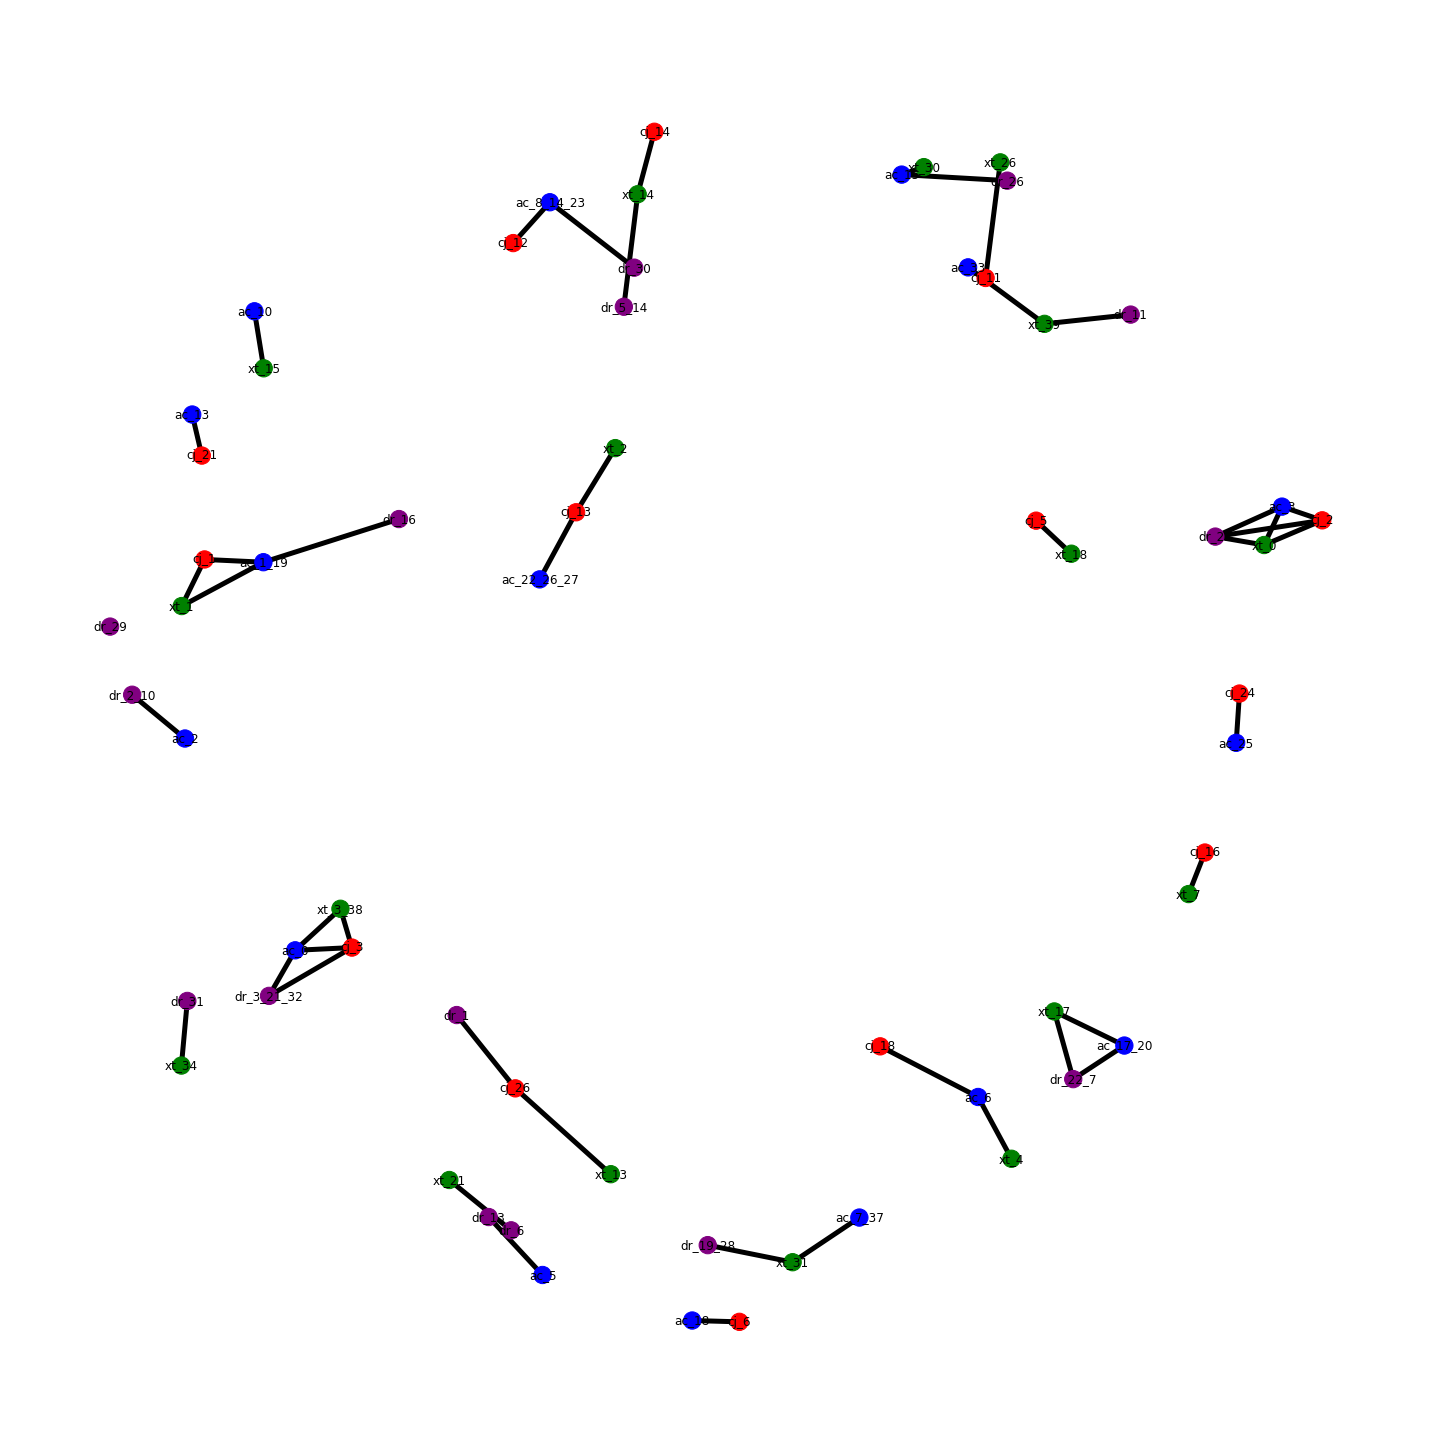

In [207]:
plt.figure(figsize = ((20,20)))
nx.draw(G_fin, pos, with_labels=True,width=5, edge_color='black',node_color = colors)
plt.show()

In [339]:
fn = 'Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_11202025.h5ad'
sam = SAM()
sam.load_data(fn)

In [340]:
fin_labels = []
for item in sam.adata.obs_names:
    if sam.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in result.keys():
        fin_labels.append(result[sam.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [341]:
sam.adata.obs['test'] = fin_labels

In [342]:
a = 0
fin_obs = []
mapping_cj = {}
for item in sam.adata.obs_names:
    if sam.adata.obs.loc[item,'ss_subclass_nounlabeled_nmm_v3_nn'] != sam.adata.obs.loc[item,'test']:
        a += 1
        if sam.adata.obs.loc[item,'ss_subclass_nounlabeled_nmm_v3_nn'] not in mapping_cj:
            mapping_cj[sam.adata.obs.loc[item,'ss_subclass_nounlabeled_nmm_v3_nn']] = set([sam.adata.obs.loc[item,'test']])
        else:
            mapping_cj[sam.adata.obs.loc[item,'ss_subclass_nounlabeled_nmm_v3_nn']].add(sam.adata.obs.loc[item,'test'])

In [343]:
mapping_cj

{'cj_ac_xt_dr_4': {'cj_ac_xt_dr_3'},
 'cj_ac_xt_dr_2': {'cj_ac_xt_dr_3'},
 'cj_xt_dr_2': {'cj_ac_xt_dr_5'},
 'xt_dr_1': {'ac_xt_dr_2'},
 'dr_3_21_32': {'cj_ac_xt_dr_1'},
 'dr_5_14': {'cj_xt_dr_2'},
 'dr_9': {'ac_dr_2'},
 'dr_13': {'ac_dr_1'},
 'cj_ac_xt_dr_3': {'cj_ac_xt_dr_4'},
 'dr_11': {'ac_xt_dr_1'},
 'dr_31': {'xt_dr_1'},
 'dr_25': {'cj_dr_2'},
 'cj_ac_xt_dr_1': {'cj_ac_xt_dr_2'},
 'dr_30': {'cj_ac_dr_1'},
 'dr_41': {'ac_dr_3'},
 'dr_34': {'cj_dr_1'}}

In [311]:
mismatch_adata = sam.adata[fin_obs,:]

In [296]:
mismatch_adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique()

['ac_15', 'cj_ac_xt_1', 'ac_5', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_3', ..., 'ac_2', 'ac_17_20', 'cj_ac_1', 'ac_6', 'ac_11']
Length: 16
Categories (16, object): ['ac_2', 'ac_5', 'ac_6', 'ac_7_37', ..., 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_3', 'cj_ac_xt_dr_4']

In [297]:
mismatch_adata.obs['test'].unique()

array(['cj_ac_xt_dr_2', 'cj_ac_xt_dr_1', 'ac_dr_1', 'cj_ac_xt_dr_3',
       'cj_ac_xt_dr_4', 'ac_xt_1', 'cj_ac_xt_dr_5', 'ac_xt_dr_1',
       'ac_dr_2', 'ac_xt_dr_2', 'cj_ac_dr_1', 'cj_ac_xt_1', 'ac_dr_3'],
      dtype=object)

In [321]:
mapping_cj

{'cj_ac_xt_1': 'cj_ac_xt_dr_1',
 'cj_8': 'cj_xt_1',
 'cj_9': 'cj_dr_1',
 'cj_ac_xt_dr_1': 'cj_ac_xt_dr_2',
 'cj_7': 'cj_dr_2',
 'cj_xt_1': 'cj_xt_2',
 'cj_xt_2': 'cj_xt_3',
 'cj_xt_6': 'cj_xt_dr_2',
 'cj_xt_3': 'cj_xt_4',
 'cj_ac_xt_dr_2': 'cj_ac_xt_dr_3',
 'cj_ac_xt_dr_3': 'cj_ac_xt_dr_4',
 'cj_ac_xt_dr_4': 'cj_ac_xt_dr_3',
 'cj_xt_4': 'cj_ac_xt_1',
 'cj_xt_dr_2': 'cj_ac_xt_dr_5',
 'cj_ac_1': 'cj_ac_dr_1',
 '124 MPN-MPO-PVpo Hmx2 Glut': 'cj_xt_dr_2'}

In [322]:
mapping_ac

{'ac_15': 'cj_ac_xt_dr_2',
 'cj_ac_xt_1': 'cj_ac_xt_dr_1',
 'ac_5': 'ac_dr_1',
 'cj_ac_xt_dr_2': 'cj_ac_xt_dr_3',
 'cj_ac_xt_dr_3': 'cj_ac_xt_dr_4',
 'ac_10': 'ac_xt_1',
 'cj_ac_xt_dr_4': 'cj_ac_xt_dr_3',
 'ac_7_37': 'cj_ac_xt_dr_5',
 'cj_ac_xt_dr_1': 'cj_ac_xt_dr_2',
 'ac_33': 'ac_xt_dr_1',
 'ac_28': 'ac_dr_2',
 'ac_2': 'cj_ac_xt_dr_3',
 'ac_17_20': 'ac_xt_dr_2',
 'cj_ac_1': 'cj_ac_dr_1',
 'ac_6': 'cj_ac_xt_1',
 'ac_11': 'ac_dr_3'}

In [323]:
mapping_xt

{'cj_xt_4': 'cj_ac_xt_1',
 'cj_ac_xt_1': 'cj_ac_xt_dr_1',
 'xt_15': 'ac_xt_1',
 'cj_xt_dr_2': 'cj_ac_xt_dr_5',
 'cj_ac_xt_dr_3': 'cj_ac_xt_dr_4',
 'cj_ac_xt_dr_4': 'cj_ac_xt_dr_3',
 'cj_xt_1': 'cj_xt_2',
 'xt_8': 'cj_xt_1',
 'cj_xt_6': 'cj_xt_dr_2',
 'cj_xt_2': 'cj_xt_3',
 'xt_dr_1': 'ac_xt_dr_2',
 'cj_xt_3': 'cj_xt_4',
 'cj_ac_xt_dr_1': 'cj_ac_xt_dr_2',
 'xt_39': 'ac_xt_dr_1',
 'xt_34': 'xt_dr_1',
 'cj_ac_xt_dr_2': 'cj_ac_xt_dr_3'}

In [324]:
mapping_dr

{'cj_ac_xt_dr_4': 'cj_ac_xt_dr_3',
 'cj_ac_xt_dr_2': 'cj_ac_xt_dr_3',
 'cj_xt_dr_2': 'cj_ac_xt_dr_5',
 'xt_dr_1': 'ac_xt_dr_2',
 'dr_3_21_32': 'cj_ac_xt_dr_1',
 'dr_5_14': 'cj_xt_dr_2',
 'dr_9': 'ac_dr_2',
 'dr_13': 'ac_dr_1',
 'cj_ac_xt_dr_3': 'cj_ac_xt_dr_4',
 'dr_11': 'ac_xt_dr_1',
 'dr_31': 'xt_dr_1',
 'dr_25': 'cj_dr_2',
 'cj_ac_xt_dr_1': 'cj_ac_xt_dr_2',
 'dr_30': 'cj_ac_dr_1',
 'dr_41': 'ac_dr_3',
 'dr_34': 'cj_dr_1'}

In [197]:
fin_labels = []
for item in sam.adata.obs_names:
    if sam.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in result.keys():
        fin_labels.append(result[sam.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [198]:
sam.adata.obs['ss_subclass_nounlabeled_nmm_v2'] = fin_labels

In [199]:
sam.adata.obs['ss_subclass_nounlabeled_nmm_v2'].unique()

array(['dr_14', '322 Tanycyte NN', 'cj_ac_xt_dr_4', 'dr_4', '333 Endo NN',
       'cj_xt_dr_1', 'dr_8', '337 DC NN', '326 OPC NN', '330 VLMC NN',
       'cj_ac_xt_dr_2', 'cj_xt_dr_3', '328 OEC NN', 'xt_dr_1',
       '057 NDB-SI-MA-STRv Lhx8 Gaba', 'dr_24', '056 Sst Chodl Gaba',
       'dr_15', '070 LSX Prdm12 Slit2 Gaba', '038 DG-PIR Ex IMN',
       'dr_3_21_32', '327 Oligo NN', 'cj_xt_dr_2', 'dr_20', 'dr_21',
       '101 ZI Pax6 Gaba', 'dr_17', 'dr_9', 'dr_13', 'dr_35', 'dr_0',
       'cj_ac_xt_dr_3', 'dr_18', '086 MPO-ADP Lhx8 Gaba',
       '104 TU-ARH Otp Six6 Gaba', '107 DMH Hmx2 Gaba', 'xt_dr_2',
       '132 AHN-RCH-LHA Otp Fezf1 Glut', 'dr_12', '041 OB-in Frmd7 Gaba',
       '111 TRS-BAC Sln Glut', '075 MEA-BST Lhx6 Nr2e1 Gaba',
       '045 OB-STR-CTX Inh IMN', 'xt_dr_3', 'dr_37', 'dr_m041_m064',
       'dr_40', '128 VMH Fezf1 Glut', 'cj_dr_2', 'dr_39', 'cj_ac_xt_dr_1',
       '131 LHA-AHN-PVH Otp Trh Glut', '338 Lymphoid NN',
       '323 Ependymal NN', 'dr_36', '077 CEA-BST Gal 

In [200]:
sam.save_anndata(fn)

In [257]:
fin_labels = []
for item in sam_cj.adata.obs_names:
    if sam_cj.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in all_mappings_rev.keys():
        fin_labels.append(all_mappings_rev[sam_cj.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam_cj.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [258]:
sam_cj.adata.obs['ss_subclass_nounlabeled_nmm'] = fin_labels

In [259]:
sam_cj.save_anndata('Active_SAM_joined/SAM_CJ_joined_v2_cleaned_geneexp_NN_06192025.h5ad')

In [260]:
fin_labels = []
for item in sam_ac.adata.obs_names:
    if sam_ac.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in all_mappings_rev.keys():
        fin_labels.append(all_mappings_rev[sam_ac.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam_ac.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [261]:
sam_ac.adata.obs['ss_subclass_nounlabeled_nmm'] = fin_labels

In [263]:
sam_ac.save_anndata('Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_NN_geneexp_06192025.h5ad')

In [264]:
fin_labels = []
for item in sam_xt.adata.obs_names:
    if sam_xt.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in all_mappings_rev.keys():
        fin_labels.append(all_mappings_rev[sam_xt.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam_xt.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [265]:
sam_xt.adata.obs['ss_subclass_nounlabeled_nmm'] = fin_labels

In [267]:
sam_xt.save_anndata('Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_NN_geneexp_06192025.h5ad')

In [268]:
fin_labels = []
for item in sam_dr.adata.obs_names:
    if sam_dr.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in all_mappings_rev.keys():
        fin_labels.append(all_mappings_rev[sam_dr.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam_dr.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [269]:
sam_dr.adata.obs['ss_subclass_nounlabeled_nmm'] = fin_labels

In [271]:
sam_dr.save_anndata('Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_06192025.h5ad')